# 02 Object Detection Baseline

This notebook is the primary Week 2 detector-first baseline for the current project. It validates the Kaggle P&ID Symbols dataset, prepares a zero-based YOLO workspace, runs **pre-training** inference on one sample tile, trains a YOLO detector, validates the resulting checkpoint, and then runs **post-training** inference on the same sample tile for a direct before/after comparison.

Current dataset root:

- `C:/Users/jimmy/Downloads/pidset`
- sample comparison tile: `9_640_640.jpg`
- split files: `train (2).txt` and `val (1).txt`


In [1]:
from pathlib import Path
import platform
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

from ultralytics import YOLO, __version__ as ultralytics_version

plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["axes.grid"] = False


In [2]:
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from detection.helpers import (
    build_class_name_map,
    collect_dataset_integrity,
    draw_boxes,
    image_path_from_name,
    label_path_from_name,
    load_image_rgb,
    materialize_zero_based_detection_dataset,
    normalize_ultralytics_results,
    parse_tile_name,
    prediction_summary,
    read_split_file,
    read_yolo_annotations,
    render_prediction_overlay,
    save_json,
    scan_class_distribution,
    write_ultralytics_dataset_yaml,
    yolo_to_pixel_boxes,
)

DATASET_ROOT = Path(r"C:\Users\jimmy\Downloads\pidset")
IMAGE_DIR = DATASET_ROOT / "images (3)"
LABEL_DIR = DATASET_ROOT / "labels (2)"
TRAIN_SPLIT = DATASET_ROOT / "train (2).txt"
VAL_SPLIT = DATASET_ROOT / "val (1).txt"

OUTPUT_ROOT = REPO_ROOT / "outputs" / "detection"
RUNS_DIR = OUTPUT_ROOT / "runs"
OVERLAYS_DIR = OUTPUT_ROOT / "overlays"
REPORTS_DIR = OUTPUT_ROOT / "reports"
PREPARED_ROOT = REPO_ROOT / "data" / "processed" / "detection_yolo32_zero_based"
DATASET_CONFIG_PATH = PREPARED_ROOT / "pidset_detector.yaml"

MODEL_NAME = "yolo11n.pt"
SAMPLE_IMAGE_NAME = "9_640_640.jpg"
SAMPLE_IMAGE_PATH = IMAGE_DIR / SAMPLE_IMAGE_NAME

for directory in [RUNS_DIR, OVERLAYS_DIR, REPORTS_DIR, PREPARED_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)


In [3]:
print("python:", sys.version.split()[0])
print("platform:", platform.platform())
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda build:", torch.version.cuda)
print("device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
print("ultralytics:", ultralytics_version)

for path in [REPO_ROOT, DATASET_ROOT, IMAGE_DIR, LABEL_DIR, TRAIN_SPLIT, VAL_SPLIT, SAMPLE_IMAGE_PATH]:
    print(path, "->", path.exists())

python: 3.10.10
platform: Windows-10-10.0.22621-SP0
torch: 2.13.0+cpu
cuda available: False
cuda build: None
device name: cpu
ultralytics: 8.4.104
C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin -> True
C:\Users\jimmy\Downloads\pidset -> True
C:\Users\jimmy\Downloads\pidset\images (3) -> True
C:\Users\jimmy\Downloads\pidset\labels (2) -> True
C:\Users\jimmy\Downloads\pidset\train (2).txt -> True
C:\Users\jimmy\Downloads\pidset\val (1).txt -> True
C:\Users\jimmy\Downloads\pidset\images (3)\9_640_640.jpg -> True


## Split Helpers

In [4]:
train_images = read_split_file(TRAIN_SPLIT)
val_images = read_split_file(VAL_SPLIT)

print("train images:", len(train_images))
print("val images:", len(val_images))
print("train sample:", train_images[:3])
print("val sample:", val_images[:3])
print("sample tile parse:", parse_tile_name(SAMPLE_IMAGE_NAME))

train images: 27000
val images: 3000
train sample: ['73_1280_1280.jpg', '142_2560_3200.jpg', '311_1920_4480.jpg']
val sample: ['246_2560_0.jpg', '75_1920_2560.jpg', '321_1920_2560.jpg']
sample tile parse: {'tile_name': '9_640_640', 'diagram_id': '9', 'crop_x': 640, 'crop_y': 640}


## Dataset Integrity Checks

In [5]:
train_integrity = collect_dataset_integrity(IMAGE_DIR, LABEL_DIR, train_images)
val_integrity = collect_dataset_integrity(IMAGE_DIR, LABEL_DIR, val_images)

integrity_df = pd.DataFrame([
    {"split": "train", **train_integrity},
    {"split": "val", **val_integrity},
])
integrity_df

,split,images_listed,missing_images,missing_labels,empty_labels,invalid_rows
0,train,27000,0,0,4451,0
1,val,3000,0,0,482,0


## Class Distribution Scan

In [6]:
train_class_df = scan_class_distribution(LABEL_DIR, train_images)
val_class_df = scan_class_distribution(LABEL_DIR, val_images)

class_counts_df = train_class_df.merge(
    val_class_df,
    on="class_id",
    how="outer",
    suffixes=("_train", "_val"),
).fillna(0)
class_counts_df["count_train"] = class_counts_df["count_train"].astype(int)
class_counts_df["count_val"] = class_counts_df["count_val"].astype(int)
class_counts_df["count_total"] = class_counts_df["count_train"] + class_counts_df["count_val"]
class_counts_df.sort_values("class_id").reset_index(drop=True)

,class_id,count_train,count_val,count_total
0,1,5008,523,5531
1,2,5471,573,6044
2,3,5283,596,5879
3,4,5302,591,5893
4,5,5495,614,6109
5,6,5507,612,6119
6,7,5012,528,5540
7,8,5156,595,5751
8,9,5428,606,6034
9,10,5009,536,5545


## Class-Name Strategy

In [7]:
CLASS_NAME_MAP = build_class_name_map(min_class_id=1, max_class_id=32)
NUM_CLASSES = len(CLASS_NAME_MAP)
RAW_TO_ZERO_BASED = {raw_id: raw_id - 1 for raw_id in CLASS_NAME_MAP}
ZERO_BASED_TO_RAW = {zero_id: raw_id for raw_id, zero_id in RAW_TO_ZERO_BASED.items()}

print("num classes:", NUM_CLASSES)
print("class map sample:", dict(list(CLASS_NAME_MAP.items())[:5]))
print("raw->zero sample:", dict(list(RAW_TO_ZERO_BASED.items())[:5]))

num classes: 32
class map sample: {1: 'class_01', 2: 'class_02', 3: 'class_03', 4: 'class_04', 5: 'class_05'}
raw->zero sample: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}


## Class Distribution Visualization

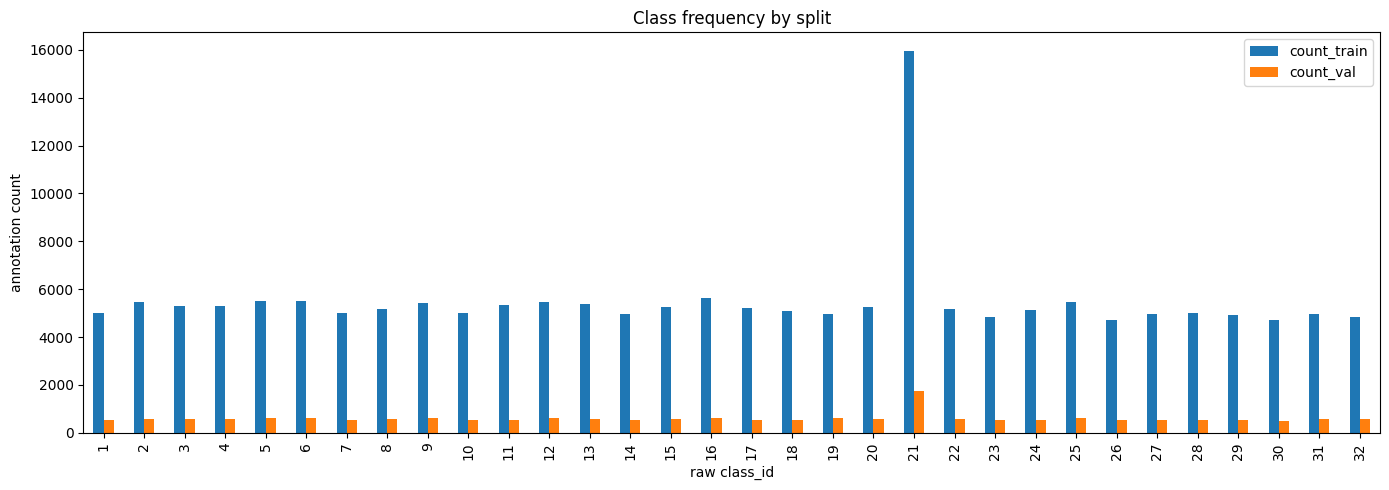

In [8]:
ax = class_counts_df.plot(
    x="class_id",
    y=["count_train", "count_val"],
    kind="bar",
    figsize=(14, 5),
    title="Class frequency by split",
)
ax.set_xlabel("raw class_id")
ax.set_ylabel("annotation count")
plt.tight_layout()

## Split Leakage Reminder

The current `train (2).txt` and `val (1).txt` split is **not diagram-isolated**. Tiles from the same original diagram appear across both splits, so validation metrics from this baseline are useful for pipeline benchmarking but should not be treated as a strict diagram-level generalization result.

## Prepare Zero-Based Detector Workspace

In [9]:
prepared_paths = materialize_zero_based_detection_dataset(
    dataset_root=DATASET_ROOT,
    prepared_root=PREPARED_ROOT,
    train_split_path=TRAIN_SPLIT,
    val_split_path=VAL_SPLIT,
)

write_ultralytics_dataset_yaml(
    dataset_yaml_path=DATASET_CONFIG_PATH,
    train_images_dir=prepared_paths["prepared_images_train"],
    val_images_dir=prepared_paths["prepared_images_val"],
    class_name_map=CLASS_NAME_MAP,
)

print("prepared train images:", prepared_paths["prepared_images_train"])
print("prepared val images:", prepared_paths["prepared_images_val"])
print("prepared train labels:", prepared_paths["prepared_labels_train"])
print("prepared val labels:", prepared_paths["prepared_labels_val"])
print("dataset yaml:", DATASET_CONFIG_PATH)
print(DATASET_CONFIG_PATH.read_text())

prepared train images: C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin\data\processed\detection_yolo32_zero_based\images\train
prepared val images: C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin\data\processed\detection_yolo32_zero_based\images\val
prepared train labels: C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin\data\processed\detection_yolo32_zero_based\labels\train
prepared val labels: C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin\data\processed\detection_yolo32_zero_based\labels\val
dataset yaml: C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin\data\processed\detection_yolo32_zero_based\pidset_detector.yaml
path: "C:\\Users\\jimmy\\Documents\\Ta\u0300i li\xEA\u0323u\\vital docs\\CODING\\\
  Python\\diagram-cognitive-twin\\data\\processed\\detection_yolo32_zero_based"
train: "C:\\Users\\jimmy\\Docum

## Ground-Truth Visualization Helpers

In [10]:
def sample_ground_truth(image_name: str):
    image_path = image_path_from_name(IMAGE_DIR, image_name)
    label_path = label_path_from_name(LABEL_DIR, image_name)
    image = load_image_rgb(image_path)
    ann_df = read_yolo_annotations(label_path)
    pixel_df = yolo_to_pixel_boxes(ann_df, image_width=image.shape[1], image_height=image.shape[0])
    return image, ann_df, pixel_df


## Show One GT Example Tile

In [11]:
gt_image, gt_ann_df, gt_pixel_df = sample_ground_truth(SAMPLE_IMAGE_NAME)
gt_overlay = draw_boxes(gt_image, gt_pixel_df, class_name_map=CLASS_NAME_MAP)

print("sample image:", SAMPLE_IMAGE_NAME)
print("sample annotation count:", len(gt_ann_df))
gt_ann_df.head()

sample image: 9_640_640.jpg
sample annotation count: 7


,class_id,x_center,y_center,width,height
0,32,0.775391,0.568750,0.099219,0.098437
1,26,0.670703,0.236328,0.097656,0.099219
2,22,0.734766,0.123047,0.041406,0.063281
3,12,0.126172,0.568750,0.074219,0.048438
4,9,0.362109,0.118359,0.075781,0.057031


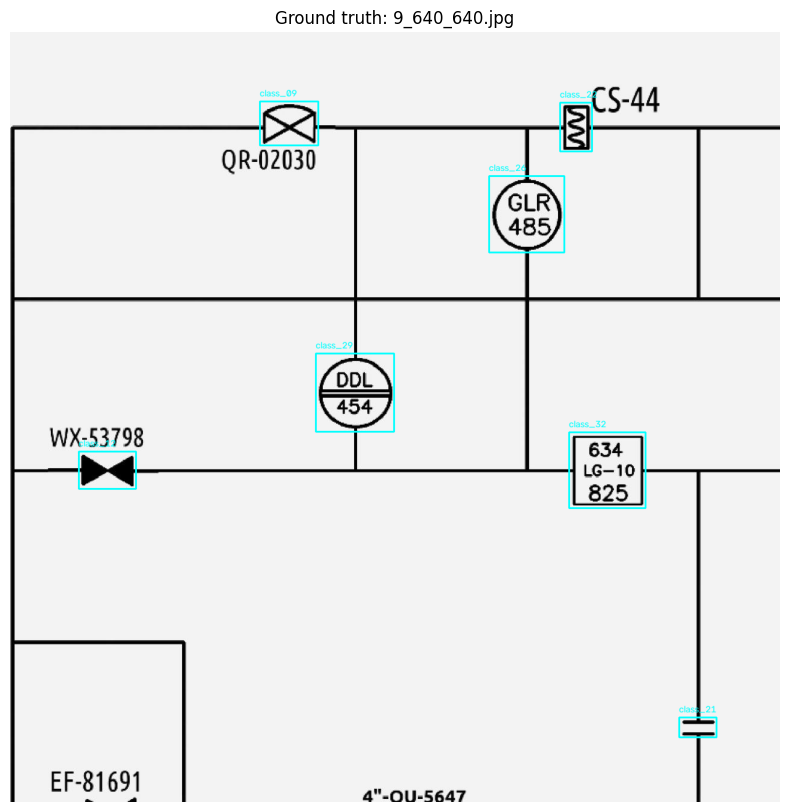

In [12]:
plt.imshow(gt_overlay)
plt.title(f"Ground truth: {SAMPLE_IMAGE_NAME}")
plt.axis("off");

## Detector Run Defaults

- Default model: `yolo11n.pt`
- Comparison tile: `9_640_640.jpg`
- Two run modes are exposed below:
  - `sanity`: short run to verify training works
  - `baseline`: longer initial baseline on the current split
- The current split is kept as-is for v1 even though it has diagram leakage.
- CPU-only execution must work for sanity checks; GPU is optional.
- Pre-training and post-training outputs are saved separately for the same tile.


In [13]:
IMGSZ = 1280
EPOCHS_SANITY = 1
EPOCHS_BASELINE = 25
BATCH_SIZE = 2 if torch.cuda.is_available() else 1
DEVICE = 0 if torch.cuda.is_available() else "cpu"
RUN_MODE = "sanity"
RUN_NAME = f"pidset_{RUN_MODE}_{MODEL_NAME.replace('.pt', '')}"
CONF_THRESHOLD = 0.25

print({
    "imgsz": IMGSZ,
    "epochs_sanity": EPOCHS_SANITY,
    "epochs_baseline": EPOCHS_BASELINE,
    "batch_size": BATCH_SIZE,
    "device": DEVICE,
    "run_mode": RUN_MODE,
    "run_name": RUN_NAME,
})

{'imgsz': 1280, 'epochs_sanity': 1, 'epochs_baseline': 25, 'batch_size': 1, 'device': 'cpu', 'run_mode': 'sanity', 'run_name': 'pidset_sanity_yolo11n'}


## Create YOLO Model Object

In [14]:
model = YOLO(MODEL_NAME)
print("model loaded:", MODEL_NAME)
print("task:", getattr(model, "task", "detect"))

model loaded: yolo11n.pt
task: detect


## Prediction-Normalization Helpers

In [15]:
def results_to_dataframe(results, run_stage: str) -> pd.DataFrame:
    rows = normalize_ultralytics_results(results, class_name_map=CLASS_NAME_MAP, run_stage=run_stage)
    return pd.DataFrame(rows)


def save_overlay_image(image_rgb: np.ndarray, output_path: Path):
    bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(output_path), bgr)


## Pre-Training Inference on Sample Tile

In [16]:
pretrain_results = model.predict(
    source=str(SAMPLE_IMAGE_PATH),
    imgsz=IMGSZ,
    conf=CONF_THRESHOLD,
    device=DEVICE,
    verbose=True,
)
pretrain_predictions_df = results_to_dataframe(pretrain_results, run_stage="pretrain")
pretrain_predictions_df


image 1/1 C:\Users\jimmy\Downloads\pidset\images (3)\9_640_640.jpg: 1280x1280 2 clocks, 556.2ms
Speed: 80.0ms preprocess, 556.2ms inference, 17.3ms postprocess per image at shape (1, 3, 1280, 1280)


,run_stage,class_id,class_name,confidence,bbox_xyxy
0,pretrain,75,class_75,0.774964,"[802.5629272460938, 246.105224609375, 916.7206..."
1,pretrain,75,class_75,0.290850,"[919.59619140625, 121.85516357421875, 962.7878..."


## Render and Save Pre-Training Overlay

saved overlay: C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin\outputs\detection\overlays\9_640_640_pretrain_overlay.png


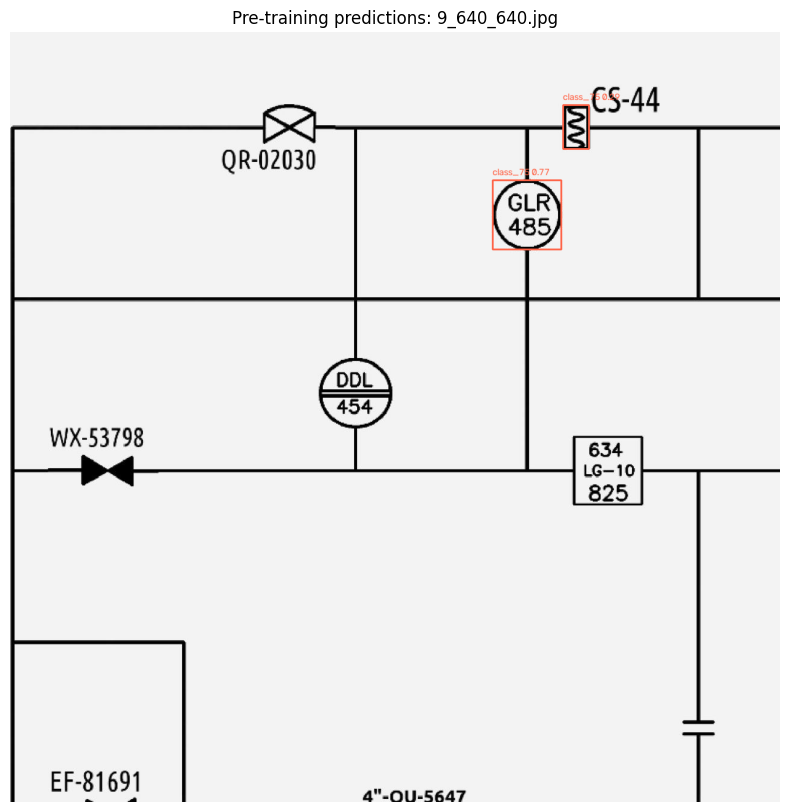

In [17]:
pretrain_overlay = render_prediction_overlay(gt_image, pretrain_predictions_df.to_dict(orient="records"))
pretrain_overlay_path = OVERLAYS_DIR / f"{Path(SAMPLE_IMAGE_NAME).stem}_pretrain_overlay.png"
save_overlay_image(pretrain_overlay, pretrain_overlay_path)
plt.imshow(pretrain_overlay)
plt.title(f"Pre-training predictions: {SAMPLE_IMAGE_NAME}")
plt.axis("off")
print("saved overlay:", pretrain_overlay_path)

## Export Pre-Training Prediction Summary JSON

In [18]:
pretrain_summary = prediction_summary(
    image_name=SAMPLE_IMAGE_NAME,
    image_path=SAMPLE_IMAGE_PATH,
    model_name=MODEL_NAME,
    run_stage="pretrain",
    predictions=pretrain_predictions_df.to_dict(orient="records"),
)
pretrain_summary_path = REPORTS_DIR / f"{Path(SAMPLE_IMAGE_NAME).stem}_pretrain_predictions.json"
save_json(pretrain_summary_path, pretrain_summary)
print("saved summary:", pretrain_summary_path)

saved summary: C:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\diagram-cognitive-twin\outputs\detection\reports\9_640_640_pretrain_predictions.json


## Pre-Training Observation Prompt

Record the qualitative behavior of the generic pretrained YOLO model here.

- Did it detect anything meaningful in the engineering tile?
- Did it predict unrelated COCO-style objects?
- Did it miss all engineering symbols?
- Is the saved overlay useful as a baseline before fine-tuning?


## Train: Sanity Run Entrypoint

In [19]:
sanity_train_results = model.train(
    data=str(DATASET_CONFIG_PATH),
    imgsz=IMGSZ,
    epochs=EPOCHS_SANITY,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=str(RUNS_DIR),
    name=f"{RUN_NAME}_sanity",
    exist_ok=True,
    workers=0,
)
sanity_train_results

Ultralytics 8.4.104  Python-3.10.10 torch-2.13.0+cpu CPU (12th Gen Intel Core(TM) i5-12450H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\jimmy\Documents\Tai liu\vital docs\CODING\Python\diagram-cognitive-twin\data\processed\detection_yolo32_zero_based\pidset_detector.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tra

KeyboardInterrupt: 

## Train: Full Baseline Entrypoint

In [ ]:
baseline_train_results = model.train(
    data=str(DATASET_CONFIG_PATH),
    imgsz=IMGSZ,
    epochs=EPOCHS_BASELINE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=str(RUNS_DIR),
    name=f"{RUN_NAME}_baseline",
    exist_ok=True,
    workers=0,
)
baseline_train_results

## Validation Metrics

In [ ]:
TRAINED_WEIGHTS_PATH = RUNS_DIR / f"{RUN_NAME}_sanity" / "weights" / "best.pt"
trained_model = YOLO(str(TRAINED_WEIGHTS_PATH))
val_results = trained_model.val(data=str(DATASET_CONFIG_PATH), imgsz=IMGSZ, batch=BATCH_SIZE, device=DEVICE)

metrics_summary = {
    "weights_path": str(TRAINED_WEIGHTS_PATH),
    "map50": float(getattr(getattr(val_results, "box", None), "map50", float("nan"))),
    "map50_95": float(getattr(getattr(val_results, "box", None), "map", float("nan"))),
    "mp": float(getattr(getattr(val_results, "box", None), "mp", float("nan"))),
    "mr": float(getattr(getattr(val_results, "box", None), "mr", float("nan"))),
}
metrics_summary_path = REPORTS_DIR / "validation_metrics_summary.json"
save_json(metrics_summary_path, metrics_summary)
metrics_summary

## Post-Training Inference on the Same Sample Tile

In [ ]:
posttrain_results = trained_model.predict(
    source=str(SAMPLE_IMAGE_PATH),
    imgsz=IMGSZ,
    conf=CONF_THRESHOLD,
    device=DEVICE,
    verbose=True,
)
posttrain_predictions_df = results_to_dataframe(posttrain_results, run_stage="posttrain")
posttrain_predictions_df

## Render and Save Post-Training Overlay

In [ ]:
posttrain_overlay = render_prediction_overlay(gt_image, posttrain_predictions_df.to_dict(orient="records"))
posttrain_overlay_path = OVERLAYS_DIR / f"{Path(SAMPLE_IMAGE_NAME).stem}_posttrain_overlay.png"
save_overlay_image(posttrain_overlay, posttrain_overlay_path)
plt.imshow(posttrain_overlay)
plt.title(f"Post-training predictions: {SAMPLE_IMAGE_NAME}")
plt.axis("off")
print("saved overlay:", posttrain_overlay_path)

## Export Post-Training Prediction Summary JSON

In [ ]:
posttrain_summary = prediction_summary(
    image_name=SAMPLE_IMAGE_NAME,
    image_path=SAMPLE_IMAGE_PATH,
    model_name=str(TRAINED_WEIGHTS_PATH),
    run_stage="posttrain",
    predictions=posttrain_predictions_df.to_dict(orient="records"),
)
posttrain_summary_path = REPORTS_DIR / f"{Path(SAMPLE_IMAGE_NAME).stem}_posttrain_predictions.json"
save_json(posttrain_summary_path, posttrain_summary)
print("saved summary:", posttrain_summary_path)

## Pre-vs-Post Comparison

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(pretrain_overlay)
axes[0].set_title("Pre-training overlay")
axes[0].axis("off")
axes[1].imshow(posttrain_overlay)
axes[1].set_title("Post-training overlay")
axes[1].axis("off")
plt.tight_layout()

comparison_summary = pd.DataFrame([
    {
        "stage": "pretrain",
        "num_detections": len(pretrain_predictions_df),
        "min_conf": float(pretrain_predictions_df["confidence"].min()) if not pretrain_predictions_df.empty else np.nan,
        "max_conf": float(pretrain_predictions_df["confidence"].max()) if not pretrain_predictions_df.empty else np.nan,
        "classes_predicted": sorted(pretrain_predictions_df["class_name"].unique().tolist()) if not pretrain_predictions_df.empty else [],
    },
    {
        "stage": "posttrain",
        "num_detections": len(posttrain_predictions_df),
        "min_conf": float(posttrain_predictions_df["confidence"].min()) if not posttrain_predictions_df.empty else np.nan,
        "max_conf": float(posttrain_predictions_df["confidence"].max()) if not posttrain_predictions_df.empty else np.nan,
        "classes_predicted": sorted(posttrain_predictions_df["class_name"].unique().tolist()) if not posttrain_predictions_df.empty else [],
    },
])

display(comparison_summary)
display(pretrain_predictions_df)
display(posttrain_predictions_df)

## Optional Qualitative Batch Preview

In [ ]:
preview_names = train_images[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, image_name in zip(axes.flat, preview_names):
    preview_path = image_path_from_name(IMAGE_DIR, image_name)
    preview_image = load_image_rgb(preview_path)
    preview_results = trained_model.predict(source=str(preview_path), imgsz=IMGSZ, conf=CONF_THRESHOLD, device=DEVICE, verbose=False)
    preview_df = results_to_dataframe(preview_results, run_stage="posttrain")
    preview_overlay = render_prediction_overlay(preview_image, preview_df.to_dict(orient="records"))
    ax.imshow(preview_overlay)
    ax.set_title(image_name, fontsize=9)
    ax.axis("off")

plt.tight_layout()

## Notebook Run Summary

- Run date:
- Model used:
- Run mode (`sanity` or `baseline`):
- Train/val split sizes:
- Pre-training sample behavior:
- Post-training sample behavior:
- Validation metrics summary:
- Next parameter to change:
